# Plot learning curves

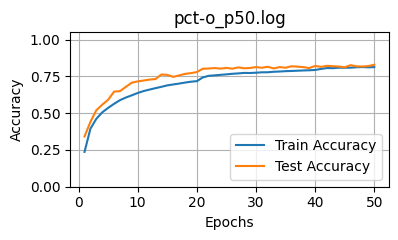

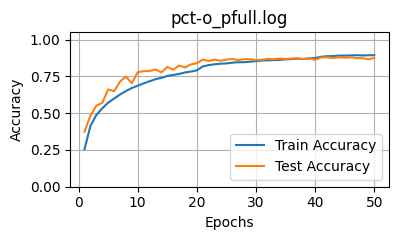

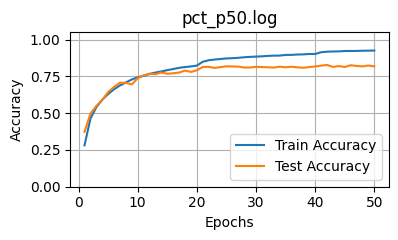

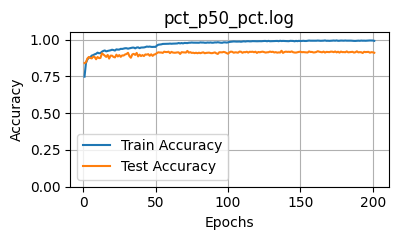

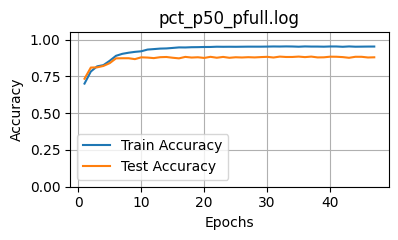

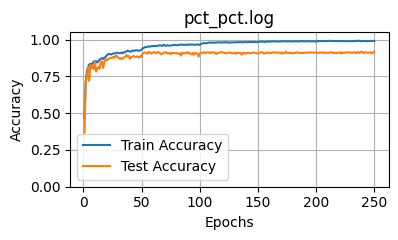

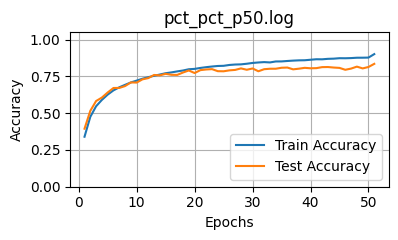

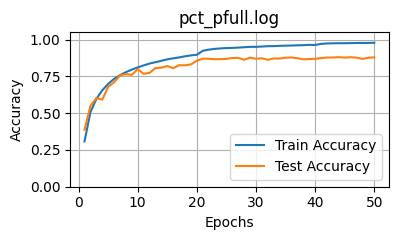

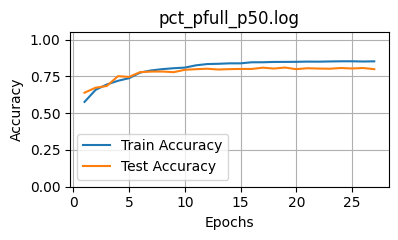

In [8]:
import os
from visuals import parse_log, plot_log

LOG_PATH = os.path.join('..', 'runs', 'logs')
PLOT_PATH = os.path.join('..', 'datasets', 'pct_plots')
os.makedirs(PLOT_PATH, exist_ok=True)
logs = os.listdir(LOG_PATH)

for log in logs:
    df = parse_log(LOG_PATH, log)
    plot_log(df, store_plots=PLOT_PATH, figsize=(4, 2.5), title=log)

# Test random occlusion

In [2]:
import open3d as o3d
import numpy as np
import trimesh
import matplotlib.pyplot as plt
import os

from mpl_toolkits.mplot3d import Axes3D  # noqa
from pathlib import Path
from visuals import visualize_cloud, visualize_samples, visualize_3d

%load_ext autoreload
%autoreload 2

In [3]:
train_points = np.load(os.path.join('..', 'datasets', 'partialmodelnet40', 'train_points.npy'))
print(train_points.shape)
print(type(train_points))

(98430, 1024, 6)
<class 'numpy.ndarray'>


In [ ]:
# Mockup of an occlusion function before I throw something similar at PCT in a pytorch setting
# In pytorch this will be done batchwise

def occlude_point_cloud(
    pc: np.ndarray,
    min_occlude: float = 0.50,
    max_occlude: float = 0.90,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    """
    Apply random plane-based occlusion to a single point cloud and
    resample back to the original number of points.

    Args:
        pc: (N, D) array. First 3 columns are xyz; remaining columns
            (e.g. normals) are kept aligned.
        min_occlude: minimum fraction of points to occlude.
        max_occlude: maximum fraction of points to occlude.
        rng: optional np.random.Generator for reproducibility.

    Returns:
        (N, D) array with occlusion applied and resampled back to N points.
    """
    if rng is None:
        rng = np.random.default_rng()

    assert pc.ndim == 2, 'pc must be (N, D)'
    N, D = pc.shape
    assert N >= 2, 'need at least 2 points'

    coords = pc[:, :3]  # xyz for geometry

    # 1) Sample occlusion fraction
    frac_occ = rng.uniform(min_occlude, max_occlude)
    k_drop = int(round(frac_occ * N))
    k_drop = max(1, min(N - 1, k_drop))

    # 2) Random plane normal
    n = rng.normal(size=3)
    n /= (np.linalg.norm(n) + 1e-8)

    # 3) Project points onto this direction
    proj = coords @ n  # (N,)

    # 4) Sort along the projection axis
    sorted_idx = np.argsort(proj)

    # Randomly choose which side to occlude: near or far
    if rng.integers(0, 2) == 0:
        # Occlude smallest projections
        keep_idx = sorted_idx[k_drop:]
    else:
        # Occlude largest projections
        keep_idx = sorted_idx[:N - k_drop]

    kept = pc[keep_idx]       # (N_keep, D)
    N_keep = kept.shape[0]

    # 5) Resample remaining points with replacement back to N
    if N_keep == N:
        return kept

    extra_idx = rng.integers(0, N_keep, size=N - N_keep)
    all_idx = np.concatenate([np.arange(N_keep), extra_idx], axis=0)

    return kept[all_idx]


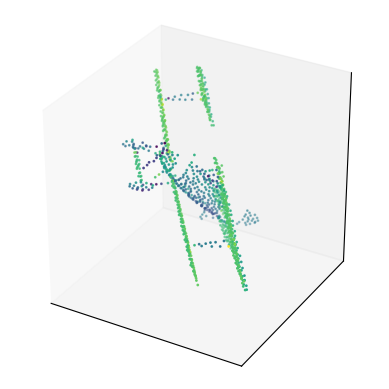

In [ ]:
# Nice example pointcloud from partial50
visualize_cloud(train_points, i=4)

In [47]:
occluded_90 = occlude_point_cloud(train_points[4], min_occlude=0.9, max_occlude=0.9)
occluded_50 = occlude_point_cloud(train_points[4], min_occlude=0.5, max_occlude=0.5)
occluded_10 = occlude_point_cloud(train_points[4], min_occlude=0.1, max_occlude=0.1)

occlusion = np.array([occluded_90, occluded_50, occluded_10, train_points[4]])

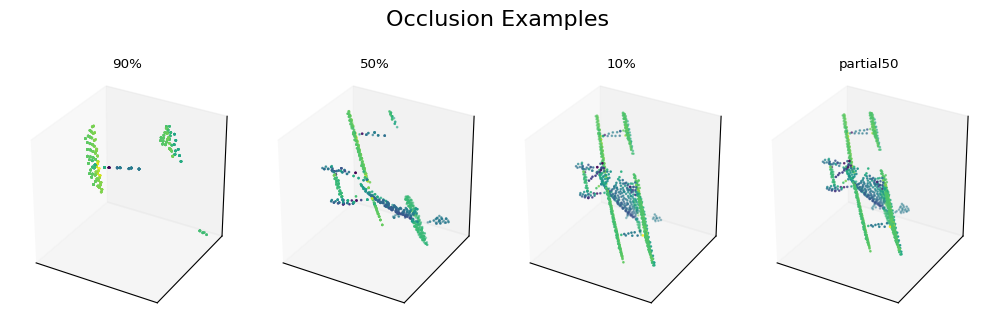

In [ ]:
# The 90% seems to be a bit...overkill
visualize_samples(occlusion, plot_dims=(1, 4), title='Occlusion Examples', labels=['90%', '50%', '10%', 'partial50'], figsize=(10, 3.5))

In [55]:
visualize_3d(occluded_50[np.newaxis, :, :], i=0)